In [1]:
from ultralytics import YOLO
import os

# Ensure working directory is the repo root
os.chdir(os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))

# Load the NEW trained model (1000 epochs, early stopped at 104)
model = YOLO('runs/detect/train2/weights/best.pt')

# Run inference on the test dataset
results = model.predict(
    source='datasets/test/images',
    save=True,
    save_txt=True,
    project='runs/detect',
    name='test_inference_v2',
    exist_ok=True,
    conf=0.25,
    iou=0.5
)

# Print summary of results
print(f"Inference completed on {len(results)} images.")
print(f"Results saved to: runs/detect/test_inference_v2")

# Display class names from the model
print(f"\nModel classes: {model.names}")

# Print detection summary for each image
for r in results:
    boxes = r.boxes
    print(f"\n{os.path.basename(r.path)}: {len(boxes)} detections")
    if len(boxes) > 0:
        for box in boxes:
            cls_id = int(box.cls[0])
            conf = float(box.conf[0])
            cls_name = model.names[cls_id]
            print(f"  - {cls_name}: {conf:.2f}")


image 1/61 /home/robot307/chinese_chess_bot_307/datasets/test/images/09025cc0-Untitled-160_jpg.rf.4a3a16652b18e8d88454750b05aba1dd.jpg: 640x640 2 b_advisors, 3 b_cannons, 3 b_chariots, 2 b_elephants, 1 b_general, 2 b_horses, 5 b_soldiers, 2 r_advisors, 3 r_cannons, 3 r_chariots, 4 r_elephants, 2 r_horses, 5 r_soldiers, 44.0ms
image 2/61 /home/robot307/chinese_chess_bot_307/datasets/test/images/10_jpg.rf.2006e411ecb4ea9c131027f3e0d0e003.jpg: 640x640 2 b_advisors, 2 b_cannons, 2 b_chariots, 2 b_elephants, 1 b_general, 2 b_horses, 5 b_soldiers, 2 r_advisors, 2 r_cannons, 2 r_chariots, 2 r_elephants, 1 r_general, 2 r_horses, 5 r_soldiers, 38.5ms
image 3/61 /home/robot307/chinese_chess_bot_307/datasets/test/images/131e38c9-Untitled-118_jpg.rf.b836ea76e5d417314941b18f10872898.jpg: 640x640 2 b_advisors, 2 b_cannons, 2 b_chariots, 2 b_elephants, 2 b_generals, 3 b_horses, 5 b_soldiers, 2 r_advisors, 2 r_cannons, 2 r_chariots, 3 r_elephants, 3 r_generals, 1 r_horse, 5 r_soldiers, 43.5ms
image 4

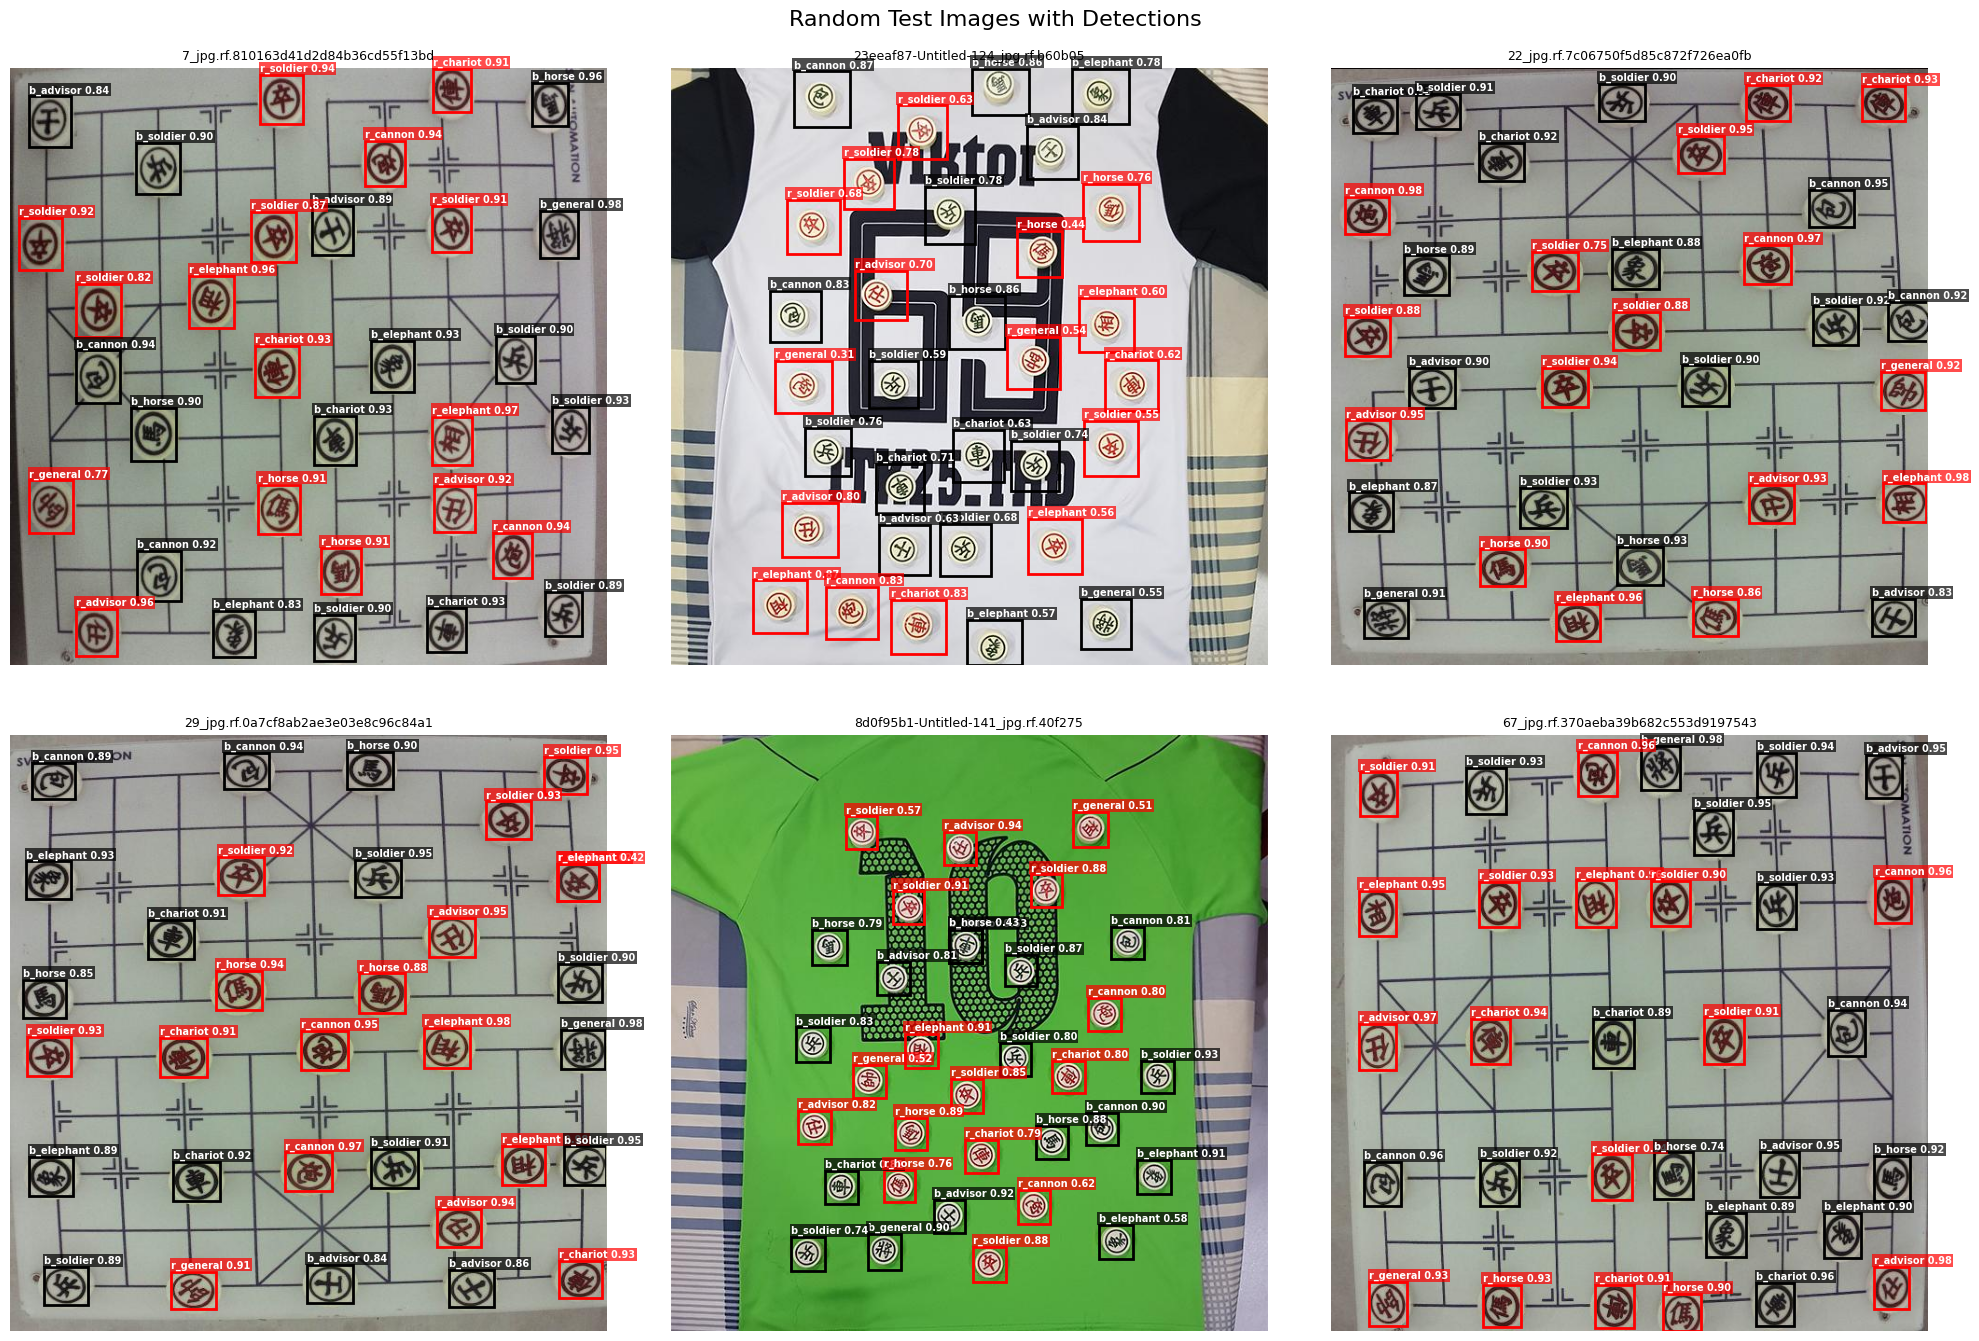

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import random
import numpy as np

# Pick 6 random results to display
sample_results = random.sample(results, min(6, len(results)))

fig, axes = plt.subplots(2, 3, figsize=(20, 14))
for ax, r in zip(axes.flat, sample_results):
    img = Image.open(r.path)
    ax.imshow(img)

    if r.boxes is not None:
        for box in r.boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            cls_id = int(box.cls[0])
            conf = float(box.conf[0])
            cls_name = model.names[cls_id]

            # Draw bounding box
            color = 'red' if cls_name.startswith('r_') else 'black'
            rect = patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=2, edgecolor=color, facecolor='none'
            )
            ax.add_patch(rect)

            # Draw label
            ax.text(x1, y1 - 4, f"{cls_name} {conf:.2f}",
                    fontsize=7, color='white', weight='bold',
                    bbox=dict(facecolor=color, alpha=0.7, pad=1, edgecolor='none'))

    ax.set_title(os.path.basename(r.path)[:35], fontsize=9)
    ax.axis('off')

# Hide unused axes if fewer than 6 images
for ax in axes.flat[len(sample_results):]:
    ax.axis('off')

plt.suptitle('Random Test Images with Detections', fontsize=16)
plt.tight_layout()
plt.show()